Activity 8

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# Load the Dataset
df = pd.read_csv("/content/brfss.csv", on_bad_lines='skip')

In [58]:
# Read 1st 5 rows of the dataframe
data = df.head(5)
data

,Unnamed: 0,age,weight2,wtyrago,wtkg2,htm3,sex
0,0,39.0,88.636364,88.636364,88.64,180.0,1
1,1,64.0,75.000000,84.545455,75.00,155.0,2
2,2,87.0,61.818182,63.636364,61.82,NaN,2
3,3,51.0,100.000000,100.000000,100.00,183.0,1
4,4,35.0,63.636364,61.363636,63.64,170.0,2


/tmp/ipykernel_753/979872836.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_counts.index, y=sex_counts.values, palette='viridis')


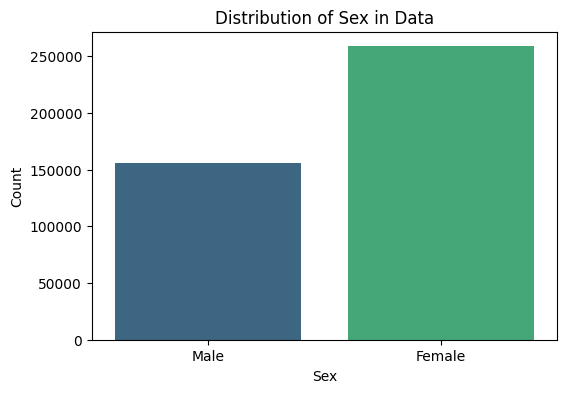

In [59]:
# Visualize the distribution of 'sex'
# First, calculate the value counts for the 'sex' column from df_cleaned
sex_counts = df ['sex'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=sex_counts.index, y=sex_counts.values, palette='viridis')
plt.title('Distribution of Sex in Data')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female']) # Assuming 1 and 2 represent male/female
plt.show()

In [60]:
# Temporarily drop the sex column for display purposes, but don't reassign df
df.drop("sex", axis=1).head()


,Unnamed: 0,age,weight2,wtyrago,wtkg2,htm3
0,0,39.0,88.636364,88.636364,88.64,180.0
1,1,64.0,75.000000,84.545455,75.00,155.0
2,2,87.0,61.818182,63.636364,61.82,NaN
3,3,51.0,100.000000,100.000000,100.00,183.0
4,4,35.0,63.636364,61.363636,63.64,170.0


In [61]:
# Use min-max algorithm to rescale the data.

df_rescaled = (df - df.min()) / (df.max() - df.min())
df_rescaled.head()

,Unnamed: 0,age,weight2,wtyrago,wtkg2,htm3,sex
0,0.000000,0.259259,0.237421,0.206259,0.237435,0.680000,0.0
1,0.000002,0.567901,0.190252,0.193457,0.190252,0.537143,1.0
2,0.000005,0.851852,0.144654,0.128023,0.144661,NaN,1.0
3,0.000007,0.407407,0.276730,0.241821,0.276730,0.697143,0.0
4,0.000010,0.209877,0.150943,0.120910,0.150956,0.622857,1.0


<Axes: >

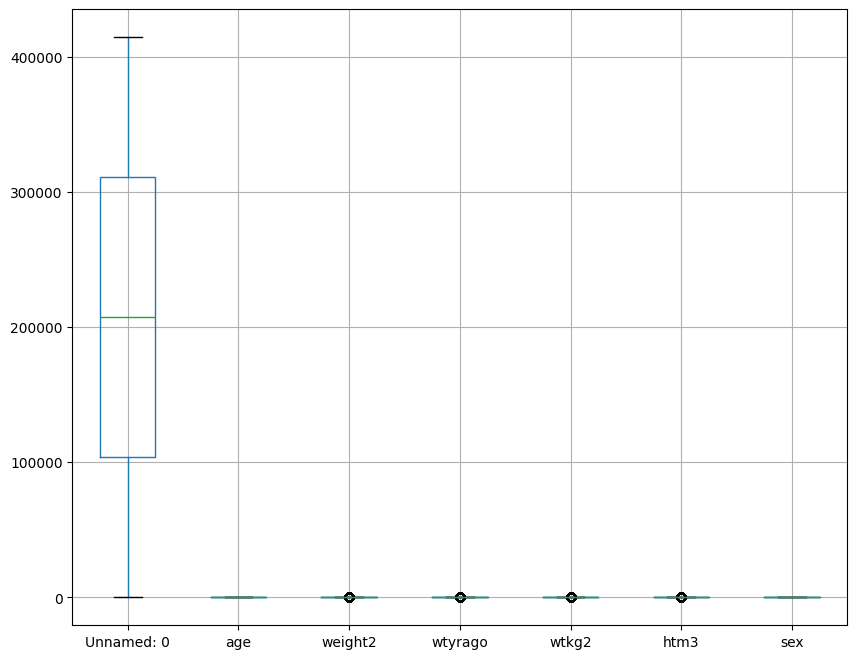

In [75]:
df.boxplot(figsize=(10, 8))

In [63]:
# Drop the rows of NAN value (every single NAN)
df_cleaned = df.dropna()
df_cleaned

,Unnamed: 0,age,weight2,wtyrago,wtkg2,htm3,sex
0,0,39.0,88.636364,88.636364,88.64,180.0,1
1,1,64.0,75.000000,84.545455,75.00,155.0,2
3,3,51.0,100.000000,100.000000,100.00,183.0,1
4,4,35.0,63.636364,61.363636,63.64,170.0,2
5,5,62.0,70.454545,70.454545,70.45,173.0,2
...,...,...,...,...,...,...,...
414499,414499,61.0,81.818182,86.363636,81.82,175.0,1
414500,414500,57.0,56.818182,58.181818,56.82,168.0,2
414501,414501,18.0,68.181818,63.636364,68.18,178.0,1
414503,414503,42.0,90.454545,90.909091,90.45,163.0,1


## Imputing Missing Values in `htm3`

Instead of simply dropping rows with `NaN` values (which can lead to loss of valuable data), we can impute missing values. For numerical features like `htm3` (height), the median is often a robust choice for imputation as it's less sensitive to outliers than the mean.

In [64]:
# Calculate the median of 'htm3' from the original df (before dropping NaNs)
median_htm3 = df['htm3'].median()

# Impute missing 'htm3' values in df_cleaned with the median
df_imputed = df_cleaned.copy()
df_imputed['htm3'] = df_imputed['htm3'].fillna(median_htm3)

print(f"Median 'htm3' used for imputation: {median_htm3}")
print("Number of NaNs in 'htm3' after imputation:", df_imputed['htm3'].isnull().sum())
display(df_imputed.head())

Median 'htm3' used for imputation: 168.0
Number of NaNs in 'htm3' after imputation: 0


,Unnamed: 0,age,weight2,wtyrago,wtkg2,htm3,sex
0,0,39.0,88.636364,88.636364,88.64,180.0,1
1,1,64.0,75.000000,84.545455,75.00,155.0,2
3,3,51.0,100.000000,100.000000,100.00,183.0,1
4,4,35.0,63.636364,61.363636,63.64,170.0,2
5,5,62.0,70.454545,70.454545,70.45,173.0,2


## Re-evaluating Outliers with Boxplots on Cleaned Data

Now that we have a cleaned and potentially imputed dataset, let's revisit visualizing potential outliers using boxplots for key numerical features. This will provide a more accurate representation than when the `df` was truncated.

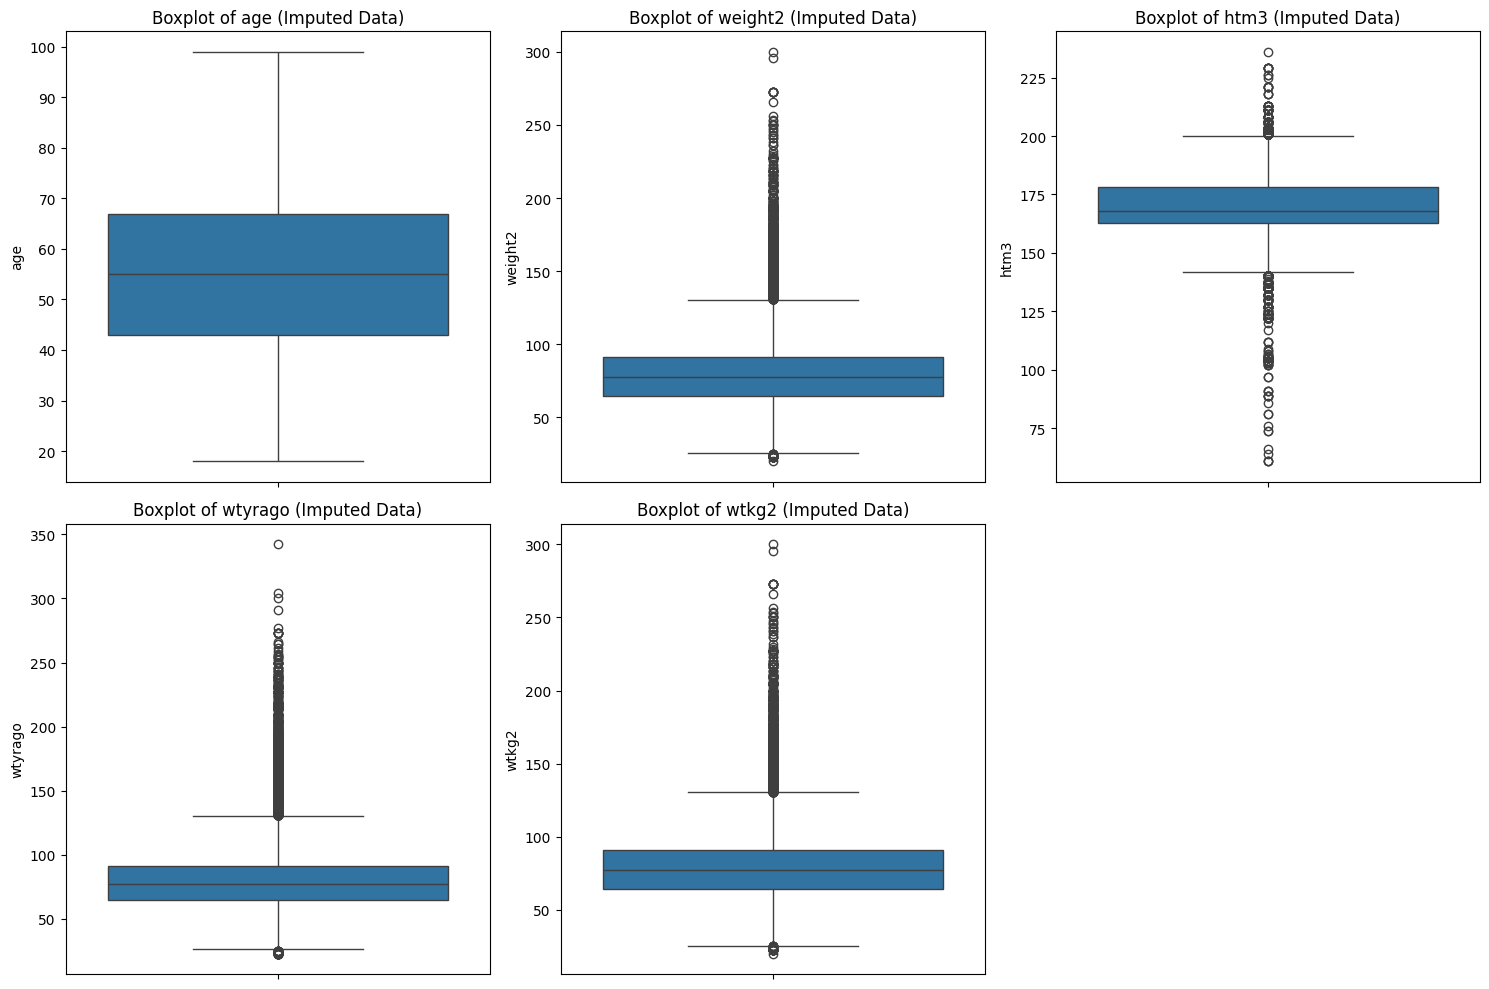

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for boxplot visualization from the imputed DataFrame
numerical_cols_for_outliers = ['age', 'weight2', 'htm3', 'wtyrago', 'wtkg2']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_imputed[col])
    plt.title(f'Boxplot of {col} (Imputed Data)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Feature Engineering: Calculating Body Mass Index (BMI)

Creating new, meaningful features from existing ones can significantly enhance your analysis and predictive models. A common feature derived from weight and height is the Body Mass Index (BMI). We'll add this to our `df_imputed` DataFrame.

BMI is calculated as: $BMI = \frac{\text{weight (kg)}}{\text{height (m)}^2}$

Given `wtkg2` (weight in kg) and `htm3` (height in cm), we need to convert height to meters.

In [66]:
# Convert height from cm to meters
df_imputed['htm_meters'] = df_imputed['htm3'] / 100

# Calculate BMI
df_imputed['bmi'] = df_imputed['wtkg2'] / (df_imputed['htm_meters']**2)

display(df_imputed[['wtkg2', 'htm3', 'htm_meters', 'bmi']].head())

,wtkg2,htm3,htm_meters,bmi
0,88.64,180.0,1.80,27.358025
1,75.00,155.0,1.55,31.217482
3,100.00,183.0,1.83,29.860551
4,63.64,170.0,1.70,22.020761
5,70.45,173.0,1.73,23.539042


## Visualize the Distribution of the Newly Created BMI Feature

Let's see the distribution of the calculated BMI values.

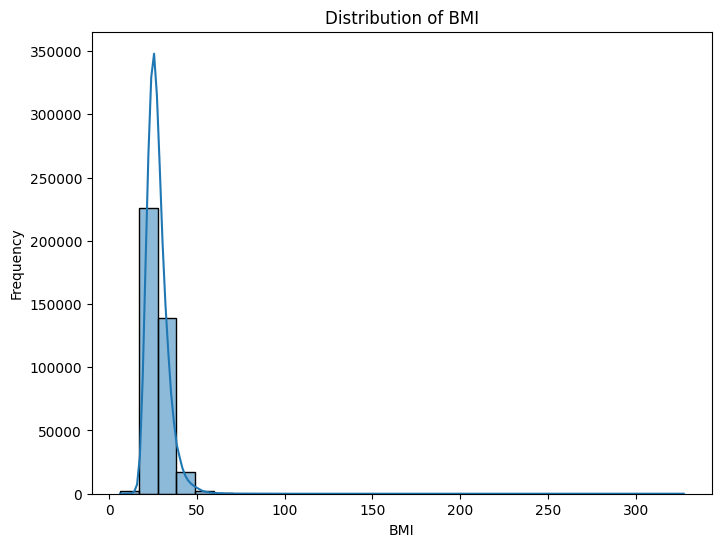

In [67]:
plt.figure(figsize=(8, 6))
sns.histplot(df_imputed['bmi'], kde=True, bins=30)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

In [68]:
df.describe()

,Unnamed: 0,age,weight2,wtyrago,wtkg2,htm3,sex
count,414509.000000,410856.000000,398484.000000,390399.000000,398484.000000,409129.000000,414509.000000
mean,207254.000000,54.862180,78.992337,79.721319,78.992453,168.825190,1.624368
std,119658.585703,16.737702,19.546212,20.565164,19.546157,10.352653,0.484286
min,0.000000,18.000000,20.000000,22.727273,20.000000,61.000000,1.000000
25%,103627.000000,43.000000,64.545455,64.545455,64.550000,160.000000,1.000000
50%,207254.000000,55.000000,77.272727,77.272727,77.270000,168.000000,2.000000
75%,310881.000000,67.000000,90.909091,90.909091,90.910000,175.000000,2.000000
max,414508.000000,99.000000,309.090909,342.272727,309.090000,236.000000,2.000000


In [69]:
df_describe = df["weight2"].describe(percentiles=[0.25, 0.50, 0.75])
df_describe

,weight2
count,398484.000000
mean,78.992337
std,19.546212
min,20.000000
25%,64.545455
50%,77.272727
75%,90.909091
max,309.090909


In [70]:
# find median and mode of age column

age_median = df["age"].median()
age_mode = df["age"].mode()
print ("Median of age_col is : ", age_median)
print ("Mode of age_col is : ", age_mode)

Median of age_col is :  55.0
Mode of age_col is :  0    60.0
Name: age, dtype: float64


## Correlation Analysis on `df_cleaned`

Let's re-examine the relationships between numerical variables using the `df_cleaned` DataFrame, which has already handled missing values. This can reveal important insights into how different features are related.

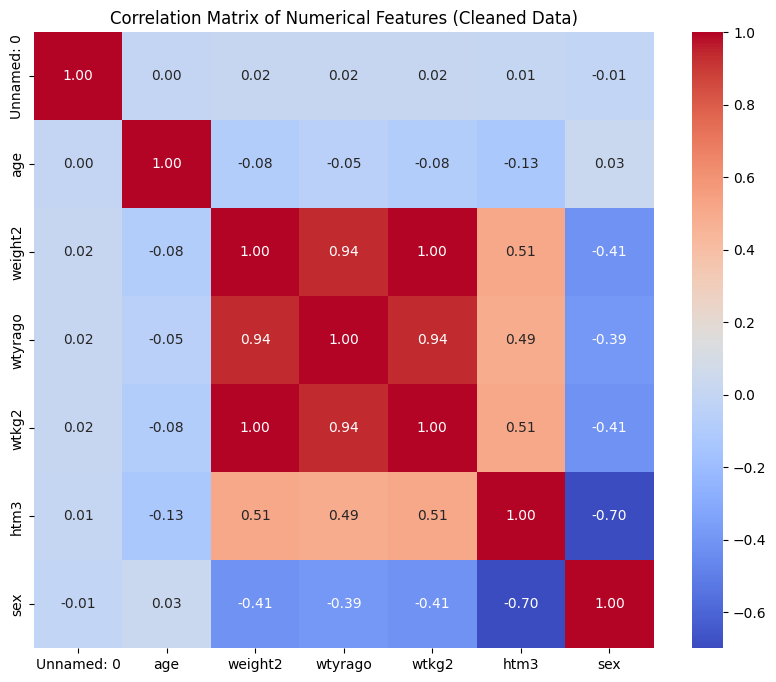

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns in df_cleaned
correlation_matrix_cleaned = df_cleaned.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features (Cleaned Data)')
plt.show()

* weight2, wtyrago, and wtkg2 show very strong positive correlations with each other (values close to 1.0), which is expected as they all relate to weight measurements.
* htm3 (height) shows a positive correlation with weight2, wtyrago, and wtkg2 (around 0.5), meaning taller individuals tend to be heavier.
* sex has a negative correlation with weight2, wtyrago, wtkg2, and htm3. This suggests that one sex group (likely 'Female' given the encoding if 2=Female) might generally have lower values for these physical measurements than the other (1=Male).
* age shows a weak negative correlation with weight2, wtyrago, and wtkg2, and a weak negative correlation with htm3 (around -0.12). * It shows a strong negative correlation with sex (around -0.4), suggesting an age distribution difference between the sexes.

Visualize Distributions of Key Numerical Features on `df_cleaned`

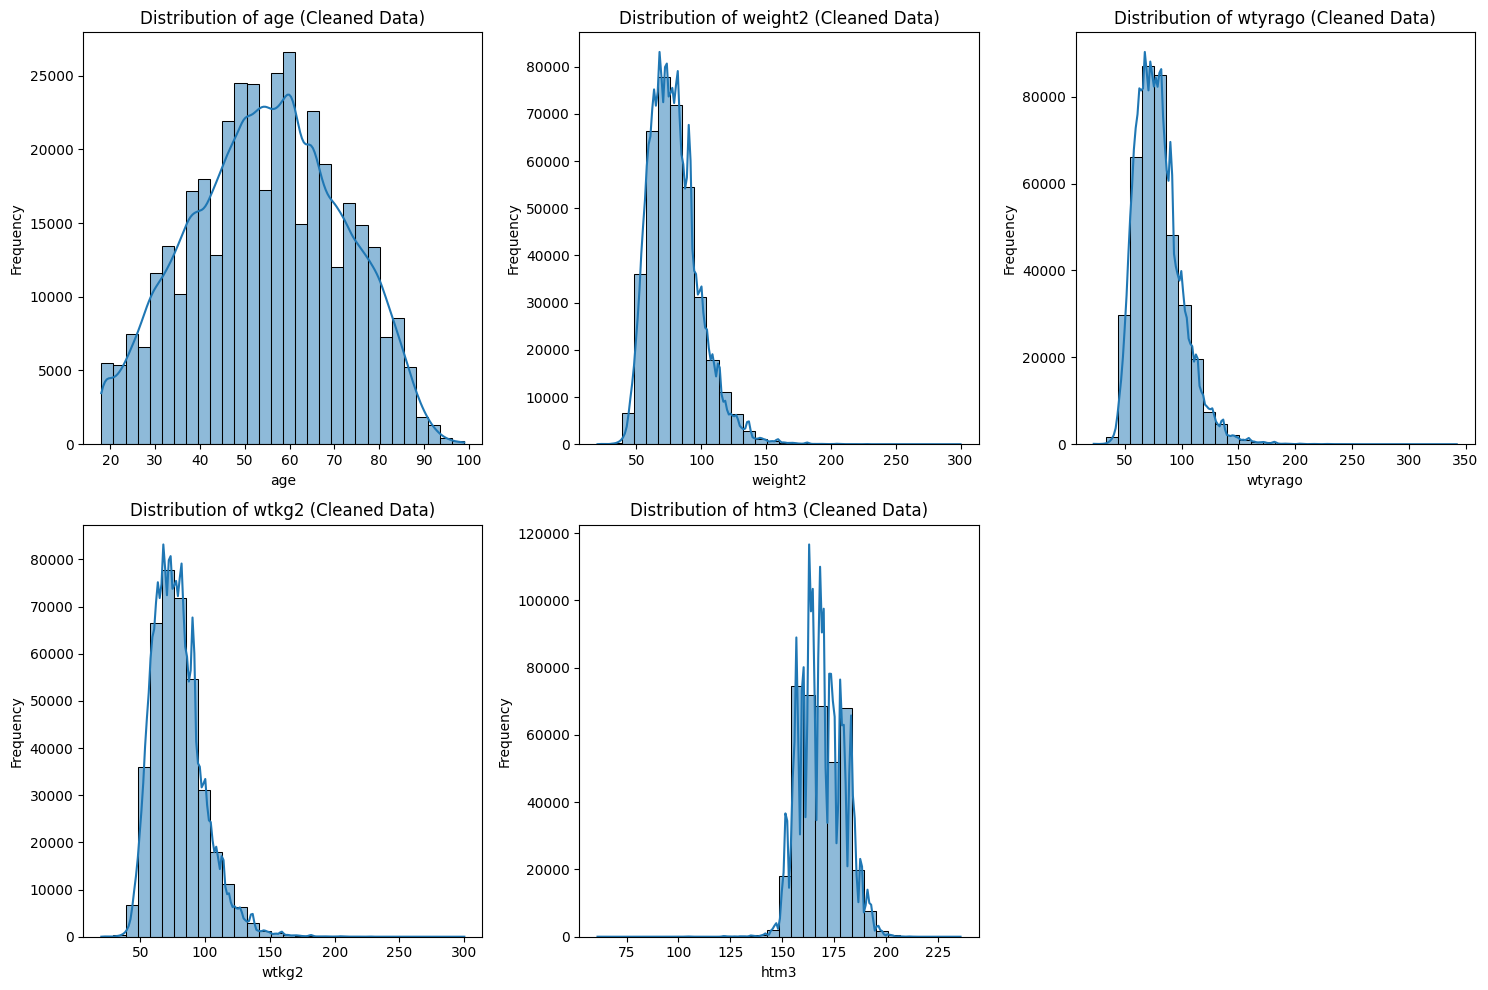

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select some numerical columns from df_cleaned to visualize their distributions
numerical_cols_cleaned = ['age', 'weight2', 'wtyrago', 'wtkg2', 'htm3']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_cleaned):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df_cleaned[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (Cleaned Data)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

* age: Likely shows a right-skewed distribution, indicating more younger adults than older adults, or a peak in middle age.
* weight2, wtyrago, wtkg2: These are all weight-related and probably show similar distributions, likely somewhat right-skewed, meaning most people fall within a certain weight range, with a tail extending to higher weights.
*htm3 (height): This is often normally distributed (bell-shaped), centered around the average human height, though it might show slight skewness depending on the population sampled.